# 1. Import Library

In [42]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


# 2. Load Data

In [43]:
df = pd.read_excel('datasets/penjualan_toko.xlsx')
df.to_csv('datasets/penjualan_toko.csv')
df.head()

,Tanggal,ID_Transaksi,Produk,Kategori,Harga,Jumlah,Kota,Metode_Pembayaran,Diskon_Persen
0,2026-01-03,TRX001,Mouse,Elektronik,150000,2,Surabaya,QRIS,10
1,2026-01-04,TRX002,Keyboard,Elektronik,275000,1,Malang,Transfer,0
2,2026-01-05,TRX003,Buku Tulis,ATK,12000,10,Jember,Tunai,5
3,2026-01-07,TRX004,Pulpen,ATK,5000,20,Situbondo,Tunai,0
4,2026-01-08,TRX005,Headset,Elektronik,350000,1,Surabaya,QRIS,15


# 3. Data Understanding

In [44]:
print("Shape:", df.shape)

print("\nColumns:")
print(df.columns)

print("\nInfo:")
df.info()

print("\nDescriptive Statistics:")
display(df.describe())

print('\nMissing Value:')
print(df.isnull().sum())

Shape: (20, 9)

Columns:
Index(['Tanggal', 'ID_Transaksi', 'Produk', 'Kategori', 'Harga', 'Jumlah',
       'Kota', 'Metode_Pembayaran', 'Diskon_Persen'],
      dtype='str')

Info:
<class 'pandas.DataFrame'>
RangeIndex: 20 entries, 0 to 19
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype
---  ------             --------------  -----
 0   Tanggal            20 non-null     str  
 1   ID_Transaksi       20 non-null     str  
 2   Produk             20 non-null     str  
 3   Kategori           20 non-null     str  
 4   Harga              20 non-null     int64
 5   Jumlah             20 non-null     int64
 6   Kota               20 non-null     str  
 7   Metode_Pembayaran  20 non-null     str  
 8   Diskon_Persen      20 non-null     int64
dtypes: int64(3), str(6)
memory usage: 1.5 KB

Descriptive Statistics:


,Harga,Jumlah,Diskon_Persen
count,2.000000e+01,20.000000,20.000000
mean,3.901000e+05,5.100000,5.750000
std,5.481179e+05,5.369505,5.946029
min,5.000000e+03,1.000000,0.000000
25%,2.875000e+04,1.000000,0.000000
50%,9.000000e+04,3.000000,5.000000
75%,5.250000e+05,6.500000,10.000000
max,1.800000e+06,20.000000,20.000000



Missing Value:
Tanggal              0
ID_Transaksi         0
Produk               0
Kategori             0
Harga                0
Jumlah               0
Kota                 0
Metode_Pembayaran    0
Diskon_Persen        0
dtype: int64


1. Shape = 20 baris, 9 kolom
2. columns = 9 kolom
3. Tipe data sudah benar
4. Tanggal, ID_transaksi, Produk, Kategori, Harga, Jumlah, Kota, Metode_Pembayaran, Diskon_Persen

# 4. Data Preprocessing

In [45]:
print("=== Missing Value ===")
print(df.isnull().sum())

print("\n=== Duplicate Data ===")
print("Jumlah data duplikat:", df.duplicated().sum())

print("\n=== Harga Tidak Valid ===")
display(df[df["Harga"] <= 0])

print("\n=== Jumlah Tidak Valid ===")
display(df[df["Jumlah"] <= 0])

print("\n=== Diskon Tidak Valid ===")
display(df[(df["Diskon_Persen"] < 0) | (df["Diskon_Persen"] > 100)])

=== Missing Value ===
Tanggal              0
ID_Transaksi         0
Produk               0
Kategori             0
Harga                0
Jumlah               0
Kota                 0
Metode_Pembayaran    0
Diskon_Persen        0
dtype: int64

=== Duplicate Data ===
Jumlah data duplikat: 0

=== Harga Tidak Valid ===


,Tanggal,ID_Transaksi,Produk,Kategori,Harga,Jumlah,Kota,Metode_Pembayaran,Diskon_Persen



=== Jumlah Tidak Valid ===


,Tanggal,ID_Transaksi,Produk,Kategori,Harga,Jumlah,Kota,Metode_Pembayaran,Diskon_Persen



=== Diskon Tidak Valid ===


,Tanggal,ID_Transaksi,Produk,Kategori,Harga,Jumlah,Kota,Metode_Pembayaran,Diskon_Persen


# Kesimpulan Data Preprocessing

1. Tidak ditemukan Missing Value
2. Tidak ditemukan Data duplikat
3. Tidak ditemukan nilai harga yang tidak valid
4. Tidak ditemukan jumlah barang yang tidak valid
5. Tidak ditemukan nilai diskon di luar rentan 0-100%
6. Datasets siap digunakan untuk tahap Exploratory Data Analysis (EDA)


# 5. Feature Engineering

In [46]:
df['Total_Penjualan'] = df['Harga'] * df['Jumlah']
df['Pendapatan_bersih'] = df['Total_Penjualan'] - (df['Total_Penjualan'] * df['Diskon_Persen'] / 100)
df

,Tanggal,ID_Transaksi,Produk,Kategori,Harga,Jumlah,Kota,Metode_Pembayaran,Diskon_Persen,Total_Penjualan,Pendapatan_bersih
0,2026-01-03,TRX001,Mouse,Elektronik,150000,2,Surabaya,QRIS,10,300000,270000.0
1,2026-01-04,TRX002,Keyboard,Elektronik,275000,1,Malang,Transfer,0,275000,275000.0
2,2026-01-05,TRX003,Buku Tulis,ATK,12000,10,Jember,Tunai,5,120000,114000.0
3,2026-01-07,TRX004,Pulpen,ATK,5000,20,Situbondo,Tunai,0,100000,100000.0
4,2026-01-08,TRX005,Headset,Elektronik,350000,1,Surabaya,QRIS,15,350000,297500.0
5,2026-01-09,TRX006,Kursi,Furniture,750000,1,Malang,Transfer,5,750000,712500.0
6,2026-01-10,TRX007,Meja,Furniture,1200000,1,Jember,Transfer,10,1200000,1080000.0
7,2026-01-11,TRX008,Lampu,Rumah Tangga,85000,3,Situbondo,QRIS,0,255000,255000.0
8,2026-01-12,TRX009,Botol Minum,Rumah Tangga,45000,4,Surabaya,E-Wallet,20,180000,144000.0
9,2026-01-13,TRX010,Flashdisk,Elektronik,95000,5,Malang,QRIS,5,475000,451250.0


# 6. Exploratory Data Analysis (EDA)

## A. Statistik Deskriptif

In [47]:
print('Rata rata harga: ', df['Harga'].mean())
print('Rata rata Jumlah Barang: ', df['Jumlah'].mean())
print('Total transaksi: ', df['ID_Transaksi'].count())


Rata rata harga:  390100.0
Rata rata Jumlah Barang:  5.1
Total transaksi:  20


1. Rata rata Harga mencapai Rp. 390.100
2. Rata rata Jumlah barang 5
3. Total transaksi 20

## B. Analisis Kategori

In [48]:
df.groupby('Kategori')['Pendapatan_bersih'].sum()

Kategori
ATK              658000.0
Elektronik      3999750.0
Furniture       3922500.0
Rumah Tangga     841500.0
Name: Pendapatan_bersih, dtype: float64

Elektronik dan Furniture adalah kategori dengan pendapatan tertinggi.

## C. Analisis Kota

In [49]:
df.groupby('Kota')['Pendapatan_bersih'].sum()

Kota
Jember       3855000.0
Malang       1881250.0
Situbondo    1414000.0
Surabaya     2271500.0
Name: Pendapatan_bersih, dtype: float64

Kota jember adalah kota dengan pendapatan yang paling tinggi dibandingkan kota lain.

## D. Analisis Produk

In [50]:
df.groupby('Produk')['Jumlah'].sum()

Produk
Botol Minum     4
Buku Tulis     10
Flashdisk       5
Gelas          12
Headset         1
Kabel USB       6
Kertas A4       3
Keyboard        1
Kursi           1
Lampu           3
Lemari          1
Meja            1
Monitor         1
Mouse           2
Notebook        8
Penggaris      15
Pulpen         20
Rak Buku        1
Sapu            5
Speaker         2
Name: Jumlah, dtype: int64

Pulpen merupakan produk dengan jumlah tertinggi pada datasets ini.

## E. Analisis Metode Pembayaran

In [51]:
df.groupby('Metode_Pembayaran')['Metode_Pembayaran'].count()

Metode_Pembayaran
E-Wallet    3
QRIS        6
Transfer    6
Tunai       5
Name: Metode_Pembayaran, dtype: int64

Metode pembayaran yang sering digunakan oleh pembeli adalah metode pembayaran QRIS dan Transfer.

## F. Korelasi Harga dengan Jumlah

Text(0.5, 1.0, 'Heatmap Korelasi Harga dan Jumlah')

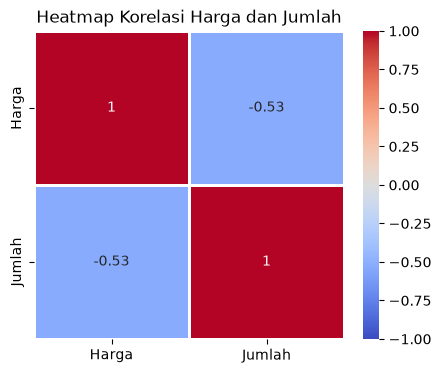

In [52]:
df_h_j = df[['Harga', 'Jumlah']]

corr = df_h_j.corr()
plt.figure(figsize=(5,4))
sns.heatmap(corr, annot=True, cmap='coolwarm', vmin=-1, vmax=1, linewidths=1,)
plt.title("Heatmap Korelasi Harga dan Jumlah")


Heatmap menunjukkan Korelasi -0.53 yang termasuk sedang pada variabel harga dan jumlah

# 7. Visualisasi data

### 1. Histogram

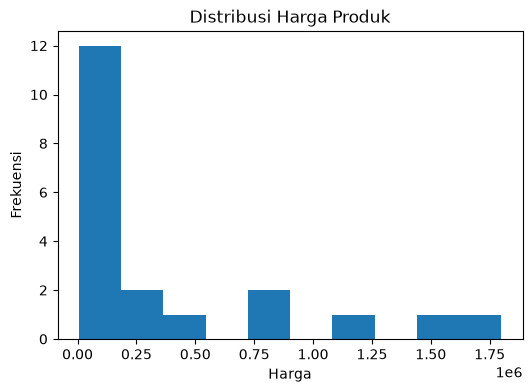

In [53]:
plt.figure(figsize=(6,4))
plt.hist(df['Harga'])

plt.title("Distribusi Harga Produk")
plt.xlabel("Harga")
plt.ylabel("Frekuensi")

plt.show()

Histogram menunjukkan distribusi harga cenderung ke kanan(right-skew).Hal ini menunjukkan bahwa sebagian besar produk memiliki harga rendah hingga menengah, sementara hanya beberapa produk yang memiliki harga tinggi.

### 2. Boxplot

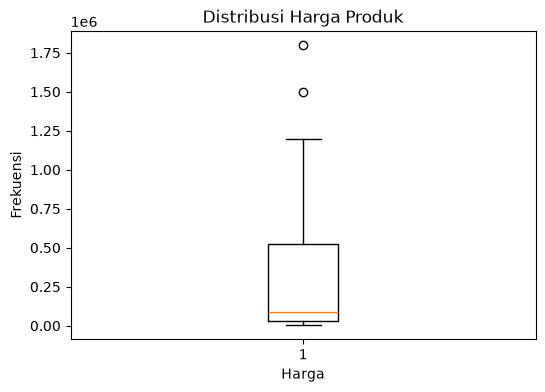

In [54]:
plt.figure(figsize=(6,4))
plt.boxplot(df['Harga'])

plt.title("Distribusi Harga Produk")
plt.xlabel("Harga")
plt.ylabel("Frekuensi")

plt.show()

Grafik Boxplot menunjukkan terdapat 2 outlier.Yaitu produk dengan harga yang jauh lebih tinggi dibanding sebagian besar harga produk lainnya

### 3. Bar Chart Pendapatan per Kategori

Text(0, 0.5, 'Frekuensi')

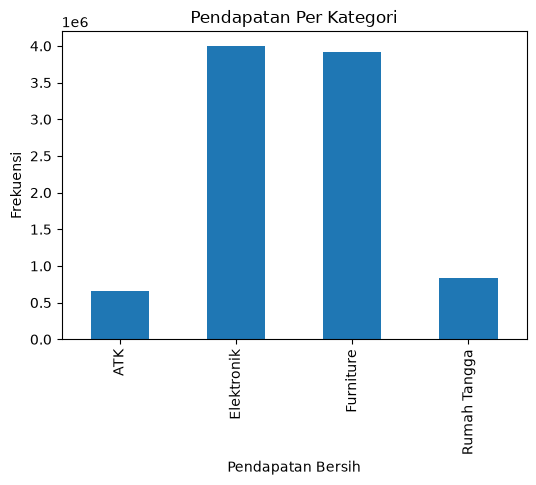

In [55]:
plt.figure(figsize=(6,4))
kategori = df.groupby("Kategori")["Pendapatan_bersih"].sum()
kategori.plot(kind='bar')


plt.title('Pendapatan Per Kategori')
plt.xlabel('Pendapatan Bersih')
plt.ylabel('Frekuensi')

Grafik menunjukkan bahwa kategori elektronik dan furnitur menghasilkan pendapatan bersih yang lebih tinggi dibanding kategori lainnya.

### 4. Bar Chart Pendapatan per Kota

Text(0, 0.5, 'Frekuensi')

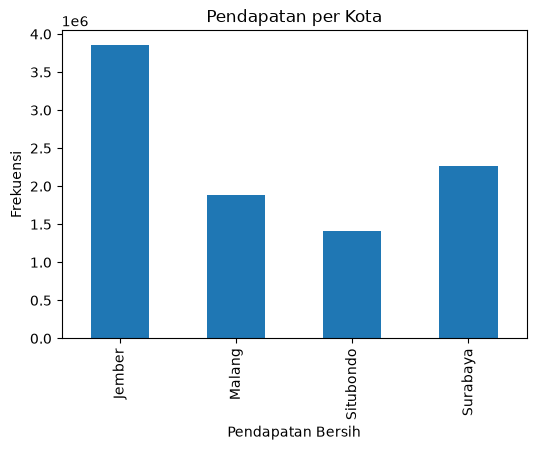

In [56]:
plt.figure(figsize=(6,4))
kota = df.groupby('Kota')['Pendapatan_bersih'].sum()
kota.plot(kind='bar')
plt.title('Pendapatan per Kota')
plt.xlabel('Pendapatan Bersih')
plt.ylabel('Frekuensi')

Grafik menunjukkan bahwa jember memiliki total pendapatan bersih tertinggi dibanding dengan kota lainnya pada datasets ini.

### 5. Pie Chart Metode Pembayaran

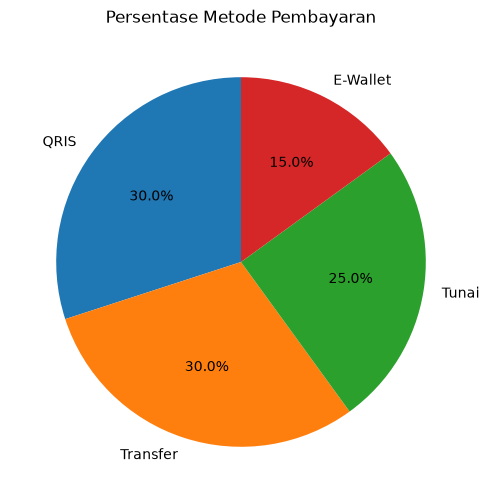

In [57]:
metode = df['Metode_Pembayaran'].value_counts()

plt.figure(figsize=(6, 6))

plt.pie(
    metode,
    labels=metode.index,
    autopct='%1.1f%%',
    startangle=90
)

plt.title('Persentase Metode Pembayaran')
plt.show()

Pie Chart menunjukkan bahwa metode pembayaran QRIS dan Transfer merupakan metode pembayaran yang sering dipakai

### 6. Scatter plot Harga vs Jumlah

Text(0, 0.5, 'Jumlah')

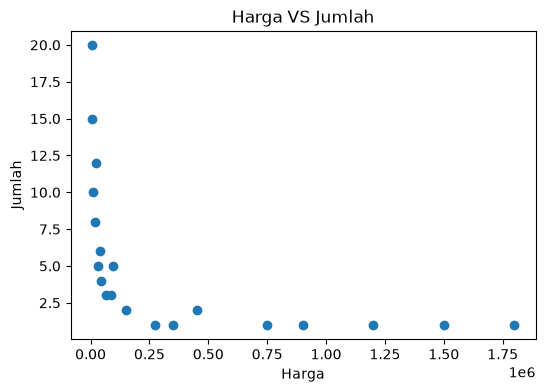

In [58]:
plt.figure(figsize=(6,4))
plt.scatter(df['Harga'], df['Jumlah'])
plt.title('Harga VS Jumlah')
plt.xlabel('Harga')
plt.ylabel('Jumlah')

Scatter Plot menunjukkan hubungan negatif antara harga dengan jumlah pembelian.Produk dengan harga lebih tinggi cenderung dibeli dalam jumlah yang lebih sedikit.

### 7. Heatmap

<Axes: title={'center': 'Heatmap'}>

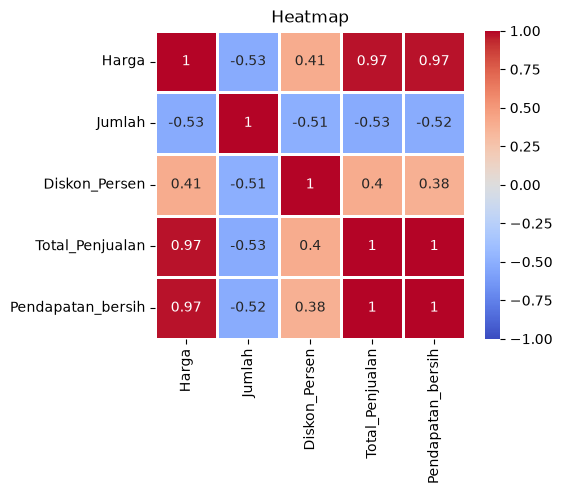

In [59]:
plt.figure(figsize=(5,4))
df_numeric = df[['Harga','Jumlah','Diskon_Persen','Total_Penjualan', 'Pendapatan_bersih']]
corr = df_numeric.corr()
plt.title('Heatmap')
sns.heatmap(corr, annot=True, cmap='coolwarm', vmin=-1, vmax=1, linewidths=1,)

Heatmap menunjukkan hubungan antar variabel numerik.Terlihat bahwa Total_Penjualan dan Pendapatan_bersih memiliki korelasi positif yang sangat kuat.Selain itu, Harga juga memiliki korelasi positif terhadap kedua variabel tersebut, menunjukkan bahwa semakin tinggi harga produk, semakin besar juga nilai penjualannya.

# 8. Insight data

#### Insight 1:
Temuan:
Berdasarkan histogram, sebagian besar produk berada pada rentan harga rendah sampai menengah, sedangkan produk dengan harga tinggi jumlahnya relatif lebih sedikit

Insight:
Distribusi ini menunjukkan bahwa toko lebih banyak menjual produk pada rentan harga rendah hingga menengah, yang mengindikasikan fokus pada pasar dengan harga yang lebih terjangkau.

Rekomendasi:
Pertahankan ketersediaan produk pada rentang harga rendah hingga menengah, dan lakukan evaluasi berkala terhadap permintaan produk berharga tinggi untuk menentukan strategi stok yang tepat.

#### Insight 2:

Temuan:
Berdasarkan boxplot, terdapat beberapa produk yang memiliki harga jauh lebih tinggi dibandingkan sebagian besar produk lainnya.

Insight:
Keberadaan produk dengan harga tinggi menunjukkan bahwa toko menyediakan produk premium selain produk dengan harga rendah hingga menengah.

Rekomendasi:
Toko dapat mengevaluasi kinerja penjualan produk premium dan menyusun strategi pemasaran yang sesuai agar produk dapat menjangkau target pelanggan yang tepat.

#### Insight 3:


Temuan:
Berdasarkan Bar chart pendapatan per kategori produk, kategori elektronik dan furnitur lebih tinggi dibanding kategori ATK dan Rumah Tangga.

Insight:
Kategori elektronik dan furnitur merupakan kontributor utama terhadap pendapatan toko.Hal ini menunjukkan bahwa kedua kategori ini memiliki peran penting dalam menghasilkan pendapatan dibanding kategori lainnya.

Rekomendasi:
Toko dapat mempertahankan ketersediaan kategori produk elektronik dan furnitur.Selain itu, toko dapat mengevaluasi penyebab rendahnya pendapatan pada kategori ATK dan Rumah Tangga untuk menentukan strategi promosi atau pengembangan produk.

#### Insight 4:

Temuan:
Berdasarkan bar chart pendapatan per kota, Jember memiliki pendapatan bersih tertinggi dibandingkan kota lainnya.

Insight:
Hal ini menunjukkan bahwa Jember memberikan kontribusi terbesar terhadap pendapatan toko pada dataset yang dianalisis.

Rekomendasi:
Toko dapat mengevaluasi faktor yang mendukung tingginya pendapatan di Jember, seperti variasi produk, strategi penjualan, atau karakteristik permintaan pelanggan. Hasil evaluasi tersebut dapat menjadi pertimbangan untuk diterapkan di kota lain.

#### Insight 5:

Temuan:
Berdasarkan pie chart metode pembayaran QRIS dan Transfer merupakan metode pembayaran yang paling sering digunakan oleh pelanggan.

Insight:
Tingginya penggunaan QRIS dan Tranfer menunjukkan bahwa kedua metode pembayaran tersebut menjadi pilihan utama pelanggan dalam melakukan transaksi pada dataset ini.

Rekomendasi:
Toko dapat memastikan layanan QRIS dan Transfer selalu tersedia dan berfungsi dengan baik.Selain itu, Toko dapat mengevaluasi penyebab penggunaan metode pembayaran lainnya untuk menentukan apakah diperlukan peningkatan layanan atau strategi promosi.

#### Insight 6:

Temuan:
Berdasarkan heatmap data numerik.Total penjualan dan pendapatan bersih memiliki korelasi positif yang sangat kuat.Selain itu harga memilki korelasi positif yang sangat kuat pada ke dua variabel tersebut.

Insight:
Korelasi positif yang sangat kuat menunjukkan bahwa perubahan Total_Penjualan berkaitan erat dengan perubahan Pendapatan_Bersih.Hal ini menunjukkan bahwa peningkatan nilai penjualan berpotensi meningkatkan pendapatan bersih toko.

Rekomendasi:
Toko dapat terus memantau perkembangan harga dan total penjualan karena keduanya berkaitan erat dengan pendapatan bersih.Selain itu, toko dapat mengevaluasi faktor lain seperti promosi, diskon, atau jenis produk untuk meningkatkan pendapatan

# 9. Kesimpulan:

Analisis ini bertujuan untuk menganalisis pola penjualan toko serta mengidentifikasi faktor-faktor yang berkaitan dengan pendapatan toko.Sebelum dilakukannya analisis, data terlebih dahulu melalui tahap Data Understanding, Data Preprocessing, dan Feature Engineering untuk memastikan kualitas data serta menghasilkan fitur baru yang mendukung proses analisis.

Hasil analisis menunjukkan kategori produk dengan pendapatan tertinggi,kota dengan pendapatan bersih terbesar, metode pembayaran yang paling sering digunakan, hubungan antara harga dan jumlah pembelian, variabel yang berkorelasi dengan pendapatan bersih, serta distribusi harga produk yang didominasi oleh rentang harga rendah hingga menengah.

Secara keseluruhan, hasil analisis ini dapat menjadi dasar dalam pengambilan keputusan toko.Toko dapat mempertahankan aspek-aspek yang memiliki kontribusi tinggi terhadap pendapatan bersih.Toko juga perlu mengevaluasi Faktor yang berpotensi untuk mengurangi pendapatan bersih.Analisis ini diharapkan dapat menjadi dasar dalam pengambilan keputusan serta penyusunan strategi penjualan di masa mendatang.